# Tentativi random di variational bayes

In [155]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [156]:
class Reservoir(nn.Module):
    def __init__(self, N, K, spectral_radius=0.9):
        super(Reservoir, self).__init__()
        
        self.N = N  # Number of reservoir neurons
        self.K = K  # Input dimension

        
        # Initialize Input Matrix (Uniform distribution is common)
        W_in = torch.rand(N, K) * 2 - 1  # Range [-1, 1]
        
        # Initialize Reservoir Matrix (Gaussian)
        W = torch.randn(N, N)
        
        # Scale Spectral Radius for stability
        # We calculate the largest eigenvalue and scale W
        with torch.no_grad():
            # Use real/imaginary parts to find the magnitude of eigenvalues
            eigenvalues = torch.linalg.eigvals(W)
            max_eig = torch.max(torch.abs(eigenvalues))
            W = W * (spectral_radius / max_eig)
        
        # Register as buffers (Fixed weights, move with model to GPU)
        self.register_buffer('W_in', W_in)
        self.register_buffer('W', W)
        
        # Internal state (Initialized to zeros)
        self.register_buffer('states', torch.zeros(1, N))
        
        self.activation = torch.tanh

    def forward(self, x, y = None):
        """
        x shape: [Batch, K]
        Returns the updated state: [Batch, N]
        """
        
        # Linear combinations: Input effect + Reservoir recurrent effect
        # We use .t() on weights because x is [Batch, K] and states is [Batch, N]
        input_part = x @ self.W_in.t()
        recurrent_part = self.states @ self.W.t()
        
        # We .detach() to ensure we don't track gradients through time steps
        self.states = self.activation(input_part + recurrent_part).detach()
        
        return self.states

    def reset_state(self, batch_size=1):
        """Clears the memory of the reservoir."""
        self.states = torch.zeros(batch_size, self.N, device=self.W.device)

The output matrix of the states update has dimension (batch_size,N)

## Dataset class

Each sample is of the type **($S_t$,$y_{t+1}$)**

In [157]:
from torch.utils.data import Dataset
from torch.utils.data import dataloader

class ESNDataset(torch.utils.data.Dataset):
    def __init__(self, states, predictions, mean=None, std=None):
        
        if mean is None or std is None:
            self.mean = predictions.mean()
            self.std = predictions.std()
        else:
            self.mean = mean
            self.std = std
            
        self.normalized_predictions = (predictions - self.mean) / self.std
        self.states = states 
    
    def __len__(self):
        return len(self.normalized_predictions)

    def __getitem__(self, index):
        return self.states[index], self.normalized_predictions[index]
    

## Create dataset for a 1D time series

In [ ]:
# Setup Parameters
N = 50          # Reservoir neurons
L = 500        # Total time series length
burnin = 50    # Initial steps to discard
train_split = 0.7

# Generate Synthetic Time Series (Sine wave + Noise)
times = torch.linspace(0, 50, L)
time_series = torch.sin(times) + torch.randn(L) * 0.1
time_series = time_series.view(L, 1) # Shape: [L, 1]

model = Reservoir(N = N, K = 1)
model.reset_state(batch_size=1)

# Generate Reservoir States
states = torch.zeros(L, N)
for t in range(L):
    sample = time_series[t]
    with torch.no_grad():
        states[t] = model(sample) 

# Alignment: State(t) predicts Target(t+1)
# We discard the first 'burnin' steps.
# states[t] matches targets[t+1]
states_all = states[burnin:-1]      # All states from burnin to L-1
targets_all = time_series[burnin+1:] # All targets from burnin+1 to L

# Split into Train and Test
split_idx = int(train_split * len(states_all))

train_states_raw = states_all[:split_idx]
train_targets_raw = targets_all[:split_idx].view(-1)

test_states_raw = states_all[split_idx:]
test_targets_raw = targets_all[split_idx:].view(-1)

# Calculate Normalization Stats (ONLY on Train set)
mu = train_targets_raw.mean()
sigma = train_targets_raw.std()

In [205]:
train_data = ESNDataset(train_states_raw, train_targets_raw, mu, sigma)
test_data = ESNDataset(test_states_raw, test_targets_raw, mu, sigma)

print(f"Total processed steps: {len(states_all)}")
print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Total processed steps: 449
Training samples: 314
Testing samples: 135


## Variational inference with Pyro

In [206]:
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
import pyro.distributions as dist
import pyro

**AutoLowRankMultivariateNormal** is a class in pyro which permits to define the covariance of the parameters as a low_rank approximation of a multinormal distribution (and this is our variational distribution). We just need to give as input the model, i.e. prior/likelihood

In [207]:
rank = int(np.ceil(np.sqrt(N)))

In [ ]:
def model(states,predictions):
    # prior
    # to_event means to treat that stuff as a single event
    R = pyro.sample("R", dist.Normal(torch.zeros(N), torch.ones(N)).to_event(1))

    # find mean of the distribution
    mean = torch.matmul(states,R)

    # likelihood
    # sample len(predictions) variable according to a normal distribution
    # with the mean obtained considering the prior and evaluate likelihood
    # given the predictions we have
    with pyro.plate("data", len(states)):
        pyro.sample("obs", dist.Normal(mean, 0.1), obs = predictions)

In [209]:
guide = AutoLowRankMultivariateNormal(model, rank=rank)

In [210]:
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

optimizer = Adam({"lr": 0.01}) 
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

## Tentative of training

In [211]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=30, shuffle=True)

In [212]:
from tqdm import tqdm

num_epochs = 100
pbar = tqdm(range(num_epochs), desc="Training Pyro ESN")

for epoch in pbar:
    total_loss = 0
    for batch_states, batch_targets in train_loader:
        loss = svi.step(batch_states, batch_targets)
        total_loss += loss
    
    avg_loss = total_loss / len(train_loader.dataset)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} - Average ELBO Loss: {avg_loss:.4f}")

Training Pyro ESN:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0 - Average ELBO Loss: 12.7991


Training Pyro ESN:  13%|█▎        | 13/100 [00:00<00:04, 21.02it/s]

Epoch 10 - Average ELBO Loss: 7.0554


Training Pyro ESN:  25%|██▌       | 25/100 [00:01<00:03, 22.61it/s]

...

Training Pyro ESN:  82%|████████▏ | 82/100 [00:03<00:00, 22.54it/s]

Epoch 80 - Average ELBO Loss: 6.4533


Training Pyro ESN:  94%|█████████▍| 94/100 [00:04<00:00, 19.21it/s]

Epoch 90 - Average ELBO Loss: 5.1235


Training Pyro ESN: 100%|██████████| 100/100 [00:04<00:00, 20.63it/s]


## test

In [213]:
from pyro.infer import Predictive

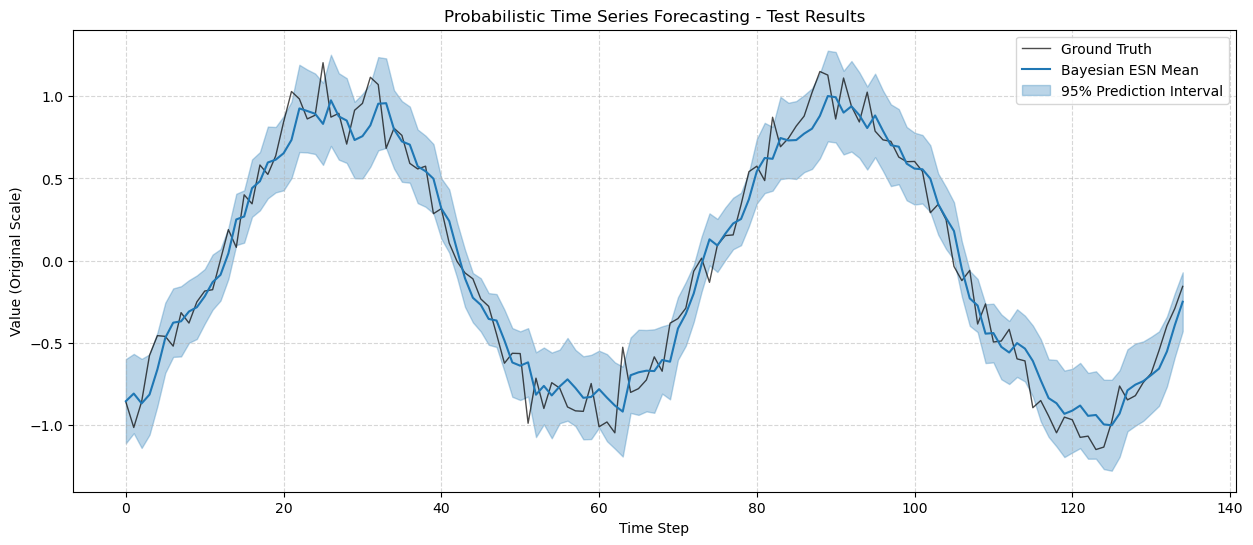

Calibration Metric (PICP): 86.67% (Target: 95.00%)
Prediction Error (RMSE): 0.1389


In [214]:
# --- TEST CONFIGURATION ---
NUM_SAMPLES = 1000  # Number of samples to estimate uncertainty
# Use the mean and std stored in your training dataset object
SCALER = {
    'mean': train_data.mean, 
    'std': train_data.std
}

def run_test_inference(model, guide, test_dataset):
    # 1. Extract data from the dataset object
    # Using the exact attribute names from the ESNDataset class
    test_states = test_dataset.states
    test_targets_norm = test_dataset.normalized_predictions

    # 2. Generate Probabilistic Predictions
    # Predictive samples weights R from the guide and computes model outputs
    predictive = Predictive(model, guide=guide, num_samples=NUM_SAMPLES)

    with torch.no_grad():
        # Passing None to the second argument (predictions) triggers sampling mode
        preds = predictive(test_states, None)
        
        # Pyro returns a dictionary. We want the "obs" site samples.
        # Shape usually: [num_samples, T_test]
        y_samples = preds["obs"] 
        
        # If your model uses plates, Pyro might return [num_samples, 1, T_test]
        # We squeeze to ensure we have [num_samples, T_test]
        if y_samples.dim() > 2:
            y_samples = y_samples.squeeze()

    # 3. Calculate Statistics (Mean and 95% Confidence Interval)
    mean_norm = y_samples.mean(dim=0)
    std_norm = y_samples.std(dim=0)
    lower_norm = mean_norm - 1.96 * std_norm
    upper_norm = mean_norm + 1.96 * std_norm

    # 4. Denormalization (Return to original scale)
    m, s = SCALER['mean'], SCALER['std']
    y_true = (test_targets_norm * s) + m
    y_pred_mean = (mean_norm * s) + m
    y_pred_lower = (lower_norm * s) + m
    y_pred_upper = (upper_norm * s) + m

    # 5. Visualization
    plt.figure(figsize=(15, 6))

    # Real Target
    plt.plot(y_true.numpy(), label="Ground Truth", color="black", linewidth=1, alpha=0.7)

    # Predicted Mean
    plt.plot(y_pred_mean.numpy(), label="Bayesian ESN Mean", color="#1f77b4", linewidth=1.5)

    # Uncertainty Area (Shaded Band)
    plt.fill_between(
        range(len(y_pred_mean)), 
        y_pred_lower.numpy(), 
        y_pred_upper.numpy(), 
        color="#1f77b4", 
        alpha=0.3, 
        label="95% Prediction Interval"
    )

    plt.title("Probabilistic Time Series Forecasting - Test Results")
    plt.ylabel("Value (Original Scale)")
    plt.xlabel("Time Step")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # 6. Uncertainty Metrics (PICP)
    # Checks how many real points actually fall within the shaded band
    within_bounds = (y_true >= y_pred_lower) & (y_true <= y_pred_upper)
    picp = within_bounds.float().mean() * 100
    print(f"Calibration Metric (PICP): {picp:.2f}% (Target: 95.00%)")
    
    # 7. Error Metric (RMSE)
    rmse = torch.sqrt(torch.mean((y_true - y_pred_mean)**2))
    print(f"Prediction Error (RMSE): {rmse:.4f}")

# --- EXECUTION ---
# Ensure your model and guide are trained before running this
run_test_inference(model, guide, test_data)